# Tutorial: Router Agentic Pattern with **Open Source AgentGrid** SDKs

- Author: Shridhar Kini
- To Securely Run: jupyter notebook password to generate onetime password for secure access
- To Run at root directory of the repo: jupyter notebook --allow-root  --port 9999 --ip=0.0.0.0
- To Clear Outputs: Use jupyter nbconvert --clear-output --inplace 4_Router_Pattern.ipynb

This walkthrough demonstrates how to build and orchestrate a `Router agentic pipeline` using the **AgentGrid SDKs**. We focus on the **Help-Desk Ticket Routing** flow, where a central router directs user requests to specialized domain experts.

## Resource Links
To Know more about the Open Source AgentGrid SDKs, please refer to the [AgentGrid Github](https://github.com/opencyber-space/AgentGr.id) or Resource [AgentGrid SDKs Documentation](https://resources.agentgr.id/) or (https://www.agentgr.id/) 

## Agentic Patterns Link
To know more about the Agentic Patterns, please refer to the [Agentic Patterns](https://www.anthropic.com/engineering/building-effective-agents) And [Video](https://www.youtube.com/watch?v=e2zIr_2JMbE) And [Blog](https://www.mattprd.com/p/the-complete-beginners-guide-to-autonomous-agents)

---

## 1. Agent LLM Interface: `agents_llm`

The `agents_llm` library provides a unified interface for model inference. This allows you to swap models (Qwen, Llama etc) without changing your agent's core logic. The models which are hosted in AIOS as blocks or the 3rd party models like OpenAI/Gemini etc also can be accessed via the `agents_llm` library. As we will use `DSpy Library` for Agentic Programming, we have created a custom class to wrap the `agents_llm` library and provide a more user-friendly interface for model inference `AIOS_DSPy_LMs` custom class

---

## 2. Orchestration & Communication: `agents_sdk`

The `agents_sdk` framework handles the "lifecycle" and "social" aspects of an agent.

### Core Data Structures
- **`AgentTask`**: Contains the `job_data` (payload) and metadata.
- **`AgentResult`**: Packages the output or error state.

### The `Context` Object
Every agent is initialized with a `Context`, providing communication handles:
1. **`p2p_manager`**: Synchronous or asynchronous peer-to-peer messaging. The Agent P2P Module enables decentralized, real-time communication between AI agents using WebSocket and HTTP. It supports direct messaging, API calls, file transfer, and remote task execution, making it ideal for distributed multi-agent coordination
2. **`delegator`**: Offloading tasks to specialized workers.
3. **`direct`**: Submitting tasks directly to other without central brokers

### Class Structure

In [ ]:
# sample_agent.py
import logging
import uuid
from typing import List, Optional

from core.agent_executor import AgentTask, AgentResult
from core.main import main
from core.agent_executor import Context

log = logging.getLogger(__name__)


class SampleAgent:

    def __init__(self, subject, context: Context) -> None:
        self.subject = subject
        self.context = context

    def get_muxer(self):
        return None

    def on_preprocess(self, task: AgentTask) -> Optional[List[AgentTask]]:

        text = task.job_data.get("text")
        if not text:
            log.warning(
                "Task %s has no 'text' in job_data, skipping.", task.task_id)
            return None

        return [task]

    def on_data(self, task: AgentTask) -> AgentResult:

        try:
            text = task.job_data["text"]
            out = text.upper()
            # Implementation logic here...
            return AgentResult(
                task_id=task.task_id,
                job_output={"text": out},
                is_error=False,
            )

        except Exception as e:
            log.exception("Error processing task %s: %s", task.task_id, e)
            return AgentResult(
                task_id=task.task_id,
                is_error=True,
                error_data={"stage": "on_data", "message": str(e)},
            )


main(SampleAgent)


### FLOW
1. Use the Base Class Template shared above, and define (specific task) what the agent Class will do with the help of AI Models and DSPy Library 
2. Use the communication entities to pass on the result of this agent to either next agents or return the response back to user 
3. Build the docker and push to registry
4. Register the Agent to registry
5. Deploy the Agent Via Deployer
6. Do inference request to the Router Agent

---

## 3. Case Study: Help-Desk Ticket Routing with Router Pattern

The Router pattern involves a central agent that orchestrates a set of specialized worker agents. In this Help-Desk case study:
1. A **Router Agent** analyzes the request and dispatches it to one or more domain-specific experts.
2. Specialized agents (**Account, Billing, Tech, Security, Compliance, CX**) process the request in parallel.
3. A **Synthesizer Agent** aggregates the outputs using a **Muxer** and provides a final response.

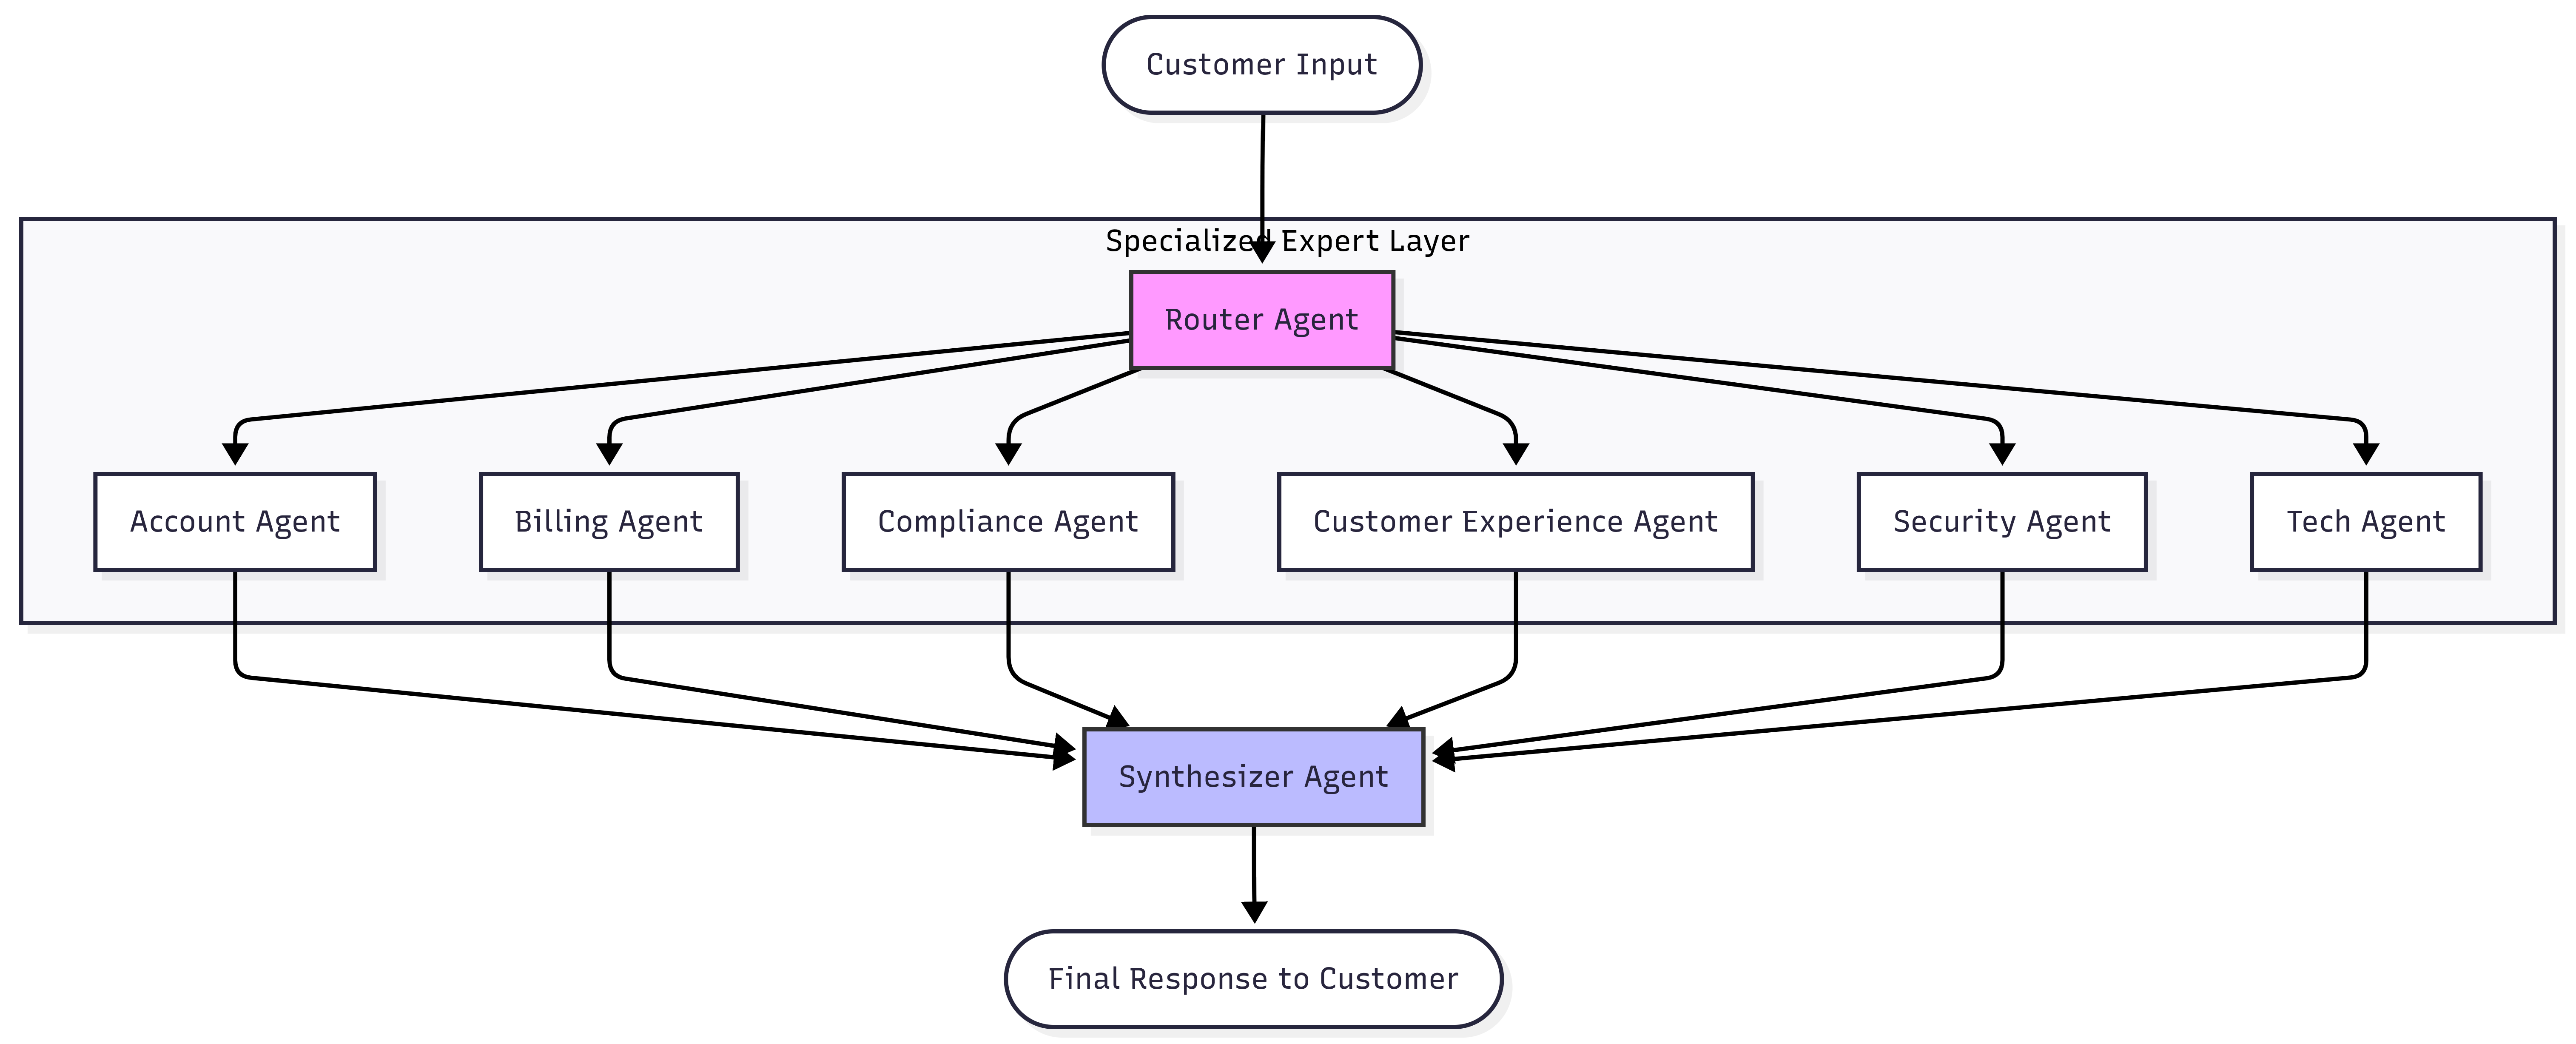

### Agent Roles & Constraints

| Agent | Role | Domain | Path |
| :--- | :--- | :--- | :--- |
| **Router Agent** | Dispatcher / Classifier | Analyzes requests and dynamically selects appropriate specialized agents for processing. | `agent_codes/agent_helpdesk_router_agent.py` |
| **Tech Agent** | Worker | Handles technical issues, bug reports, system errors, and hardware failures. | `agent_codes/agent_helpdesk_tech_agent.py` |
| **Account Agent** | Worker | Manages core identity, subscription plans, ownership, and login issues. | `agent_codes/agent_helpdesk_account_agent.py` |
| **Billing Agent** | Worker | Specializes in charges, refunds, invoice disputes, and payment processing. | `agent_codes/agent_helpdesk_billing_agent.py` |
| **Security Agent** | Worker | Assesses threats like phishing, unauthorized access, and account takeovers. | `agent_codes/agent_helpdesk_security_agent.py` |
| **Compliance Agent** | Worker | Manages Personally Identifiable Information (PII) requests, legal documentation, and privacy regulations (GDPR/CCPA). | `agent_codes/agent_helpdesk_compliance_agent.py` |
| **CX Agent** | Worker | Evaluates user sentiment and emotional state, ensuring an empathetic response. | `agent_codes/agent_helpdesk_cx_agent.py` |
| **Synthesizer Agent** | Aggregator | Collects results from all active workers via Muxer to form a cohesive final reply. | `agent_codes/agent_helpdesk_synthesizer_agent.py` |

---

## 4. Execution Pipeline

1. **Agent Registration**: Register all RFC agents in the cluster.
   - Script: [register-agents.sh](../../agents_registration/4_router_helpdesk_agents/register-agents.sh)
2. **Deployment**: Spin up containers for the RFC evaluation flow.
   - Script: [deploy-agents.sh](../../agents_registration/4_router_helpdesk_agents/deploy-agents.sh)
3. **Triggering the Flow**: Send the initial RFC text to the **Summarizer**.
   - Script: [inference_request.sh](../../agents_registration/4_router_helpdesk_agents/inference_request.sh)
4. **All in One**: Run [all.bash](../../agents_registration/4_router_helpdesk_agents/all.bash) to do 
    - `1. Remove agents if already running` 
    - `2. Unregister agent` 
    - `3. Register agent` 
    - `4. Deploy agents again` 

#### Run all.bash to setup the RFC Flow

In [ ]:
%%bash
cd ../../agents_registration/4_router_helpdesk_agents
bash all.bash

#### Check for pods in agents namespace

In [ ]:
%%bash
kubectl get pods -n agents

##### Check Containers in a Pod

In [ ]:
kubectl get pod -n agents <PODNAME> -o jsonpath='{.spec.containers[*].name}'

##### Executor Containers
- executor: ratelimiting, config management, load balancing, autoscaling etc
- Scouter: responsible for scouting jobs in Job Exchange
 
* User can define the policy for above 

#### Trigger the First agent (RouterAgent)

In [ ]:
%%bash
echo "$PWD"
cd ../../agents_registration/4_router_helpdesk_agents
echo "$PWD"
bash inference_request.sh

#### To Remove the Agent Pods

In [ ]:
%%bash
cd ../../agents_registration/4_router_helpdesk_agents
bash remove-agents.sh

---

## 5. Conclusion

The Router pattern is ideal for handling multifaceted user requests. By leveraging the **AgentGrid SDKs** and a robust **Muxer** logic, the system ensures that complex tickets are handled by the right set of experts and synthesized into a coherent user experience.